# **Problem 1**

## Basic Data Exploration & Trend Visualization


In [1]:
import pandas as pd

In [2]:
# Loading the dataset
df = pd.read_csv("/content/drive/MyDrive/Concepts and Technologies of AI/Assignment1/Human_Development_Index_Dataset.csv", encoding='latin-1')

### **Problem - 1A** - Single Year HDI Exploration (Latest Year: 2022)

**1. Extract Latest Year:**


• Identify unique years in the dataset.

In [3]:
df['year'].unique()

array([1990, 1991, 1992, 1993, 1994, 1995, 1996, 1997, 1998, 1999, 2000,
       2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011,
       2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022])

• Filter the dataset to include only observations from the year 2022.

In [4]:
filetered_df = df[df['year'] == 2022].copy()


• Save the filtered dataframe as hdi_2022_df.

In [5]:
hdi_2022_df = filetered_df

**2. Data Exploration:**:



• Display the first 10 rows of the 2022 dataset.

In [6]:
hdi_2022_df.head(10)

,Unnamed: 0,iso3,country,year,hdi,life_expectancy,pop_millions,hdi_f,hdi_m,life_expec_f,...,gender_development,gender_inequality,secondary_education_f_%,secondary_education_m_%,seats_in_parliament_f_%,seats_in_parliament_m_%,labour_participation_f_%,labour_participation_m_%,co2_emission_tons,mat_footprint_percap_tons
32,33,AFG,Afghanistan,2022,0.462,62.879,41.128771,0.332443,0.534145,66.213,...,0.622,0.665,7.042050,24.077040,27.215190,72.784810,23.33,77.09,0.306318,1.1809
65,66,ALB,Albania,2022,0.789,76.833,2.842321,0.780277,0.798432,79.472,...,0.977,0.116,82.249185,86.476634,35.714286,64.285714,56.08,69.91,1.717758,11.7367
98,99,DZA,Algeria,2022,0.745,77.129,44.903225,0.681844,0.773800,78.457,...,0.881,0.460,42.910456,46.815170,7.005254,92.994746,17.57,65.53,4.079540,8.7199
131,132,AND,Andorra,2022,0.884,83.552,0.079824,NaN,NaN,85.838,...,NaN,NaN,81.718277,84.599998,46.428571,53.571429,NaN,NaN,4.593593,NaN
164,165,AGO,Angola,2022,0.591,61.929,35.588987,0.560890,0.619680,64.541,...,0.905,0.520,21.339865,37.411946,33.636364,66.363636,74.73,78.16,0.507359,3.6568
197,198,ATG,Antigua and Barbuda,2022,0.826,79.236,0.093763,NaN,NaN,81.645,...,NaN,NaN,NaN,NaN,31.428571,68.571429,NaN,NaN,6.401056,NaN
230,231,ARG,Argentina,2022,0.849,76.064,45.510318,0.841405,0.845473,79.277,...,0.995,0.292,73.591541,71.648085,44.376900,55.623100,52.08,71.74,4.190779,14.4512
263,264,ARM,Armenia,2022,0.786,73.372,2.780469,0.795110,0.774942,78.447,...,1.026,0.198,96.001381,97.050957,35.514019,64.485981,62.80,71.84,2.531088,7.3553
296,297,AUS,Australia,2022,0.946,83.579,26.177414,0.934602,0.955941,85.453,...,0.978,0.063,94.580063,94.430069,44.493392,55.506608,62.31,71.13,14.914763,26.9245
329,330,AUT,Austria,2022,0.926,82.412,8.939617,0.911592,0.937756,84.600,...,0.972,0.048,100.000000,100.000000,40.983607,59.016393,56.55,66.69,7.399461,27.9621


• Count the number of rows and columns.

In [7]:
hdi_2022_df.shape

(206, 30)

• List all column names and their data types.

In [8]:
hdi_2022_df.dtypes

,0
Unnamed: 0,int64
iso3,object
country,object
year,int64
hdi,float64
life_expectancy,float64
pop_millions,float64
hdi_f,float64
hdi_m,float64
life_expec_f,float64


**3. Missing Values & Data Cleaning:**

• Check for missing values in each column and report total counts.


In [9]:
# Missing values per column
missing_per_column = hdi_2022_df.isnull().sum()
print("Missing values per column:\n", missing_per_column)

# Total missing values in the dataset
total_missing = hdi_2022_df.isnull().sum().sum()
print("\nTotal missing values in the dataset:", total_missing)

Missing values per column:
 Unnamed: 0                    0
iso3                          0
country                       0
year                          0
hdi                           2
life_expectancy               0
pop_millions                  0
hdi_f                        13
hdi_m                        13
life_expec_f                  0
life_expec_m                  0
expec_yr_school               1
expec_yr_school_f             1
expec_yr_school_m             1
mean_yr_school                2
mean_yr_school_f              2
mean_yr_school_m              2
gross_inc_percap              2
gross_inc_percap_f           13
gross_inc_percap_m           13
gender_development           13
gender_inequality            29
secondary_education_f_%      17
secondary_education_m_%      17
seats_in_parliament_f_%       2
seats_in_parliament_m_%       2
labour_participation_f_%     12
labour_participation_m_%     12
co2_emission_tons             2
mat_footprint_percap_tons    41
dtype: int64

• Inspect dataset for:


*   numeric columns stored as text,

In [10]:
#checking dtype of columns that should be numerics
numeric_cols = ['life_expectancy', 'mean_yr_school', 'expec_yr_school', 'gross_inc_percap', 'hdi']
print(hdi_2022_df[numeric_cols].dtypes)

life_expectancy     float64
mean_yr_school      float64
expec_yr_school     float64
gross_inc_percap    float64
hdi                 float64
dtype: object


*   inconsistent or misspelled country names,

In [11]:
# List all unique country names to check manually
hdi_2022_df['country'].unique()

array(['Afghanistan', 'Albania', 'Algeria', 'Andorra', 'Angola',
       'Antigua and Barbuda', 'Argentina', 'Armenia', 'Australia',
       'Austria', 'Azerbaijan', 'Bahamas', 'Bahrain', 'Bangladesh',
       'Barbados', 'Belarus', 'Belgium', 'Belize', 'Benin', 'Bhutan',
       'Bolivia (Plurinational State of)', 'Bosnia and Herzegovina',
       'Botswana', 'Brazil', 'Brunei Darussalam', 'Bulgaria',
       'Burkina Faso', 'Burundi', 'Cabo Verde', 'Cambodia', 'Cameroon',
       'Canada', 'Central African Republic', 'Chad', 'Chile', 'China',
       'Colombia', 'Comoros', 'Congo',
       'Congo (Democratic Republic of the)', 'Costa Rica',
       "Côte d'Ivoire", 'Croatia', 'Cuba', 'Cyprus', 'Czechia', 'Denmark',
       'Djibouti', 'Dominica', 'Dominican Republic', 'Ecuador', 'Egypt',
       'El Salvador', 'Equatorial Guinea', 'Eritrea', 'Estonia',
       'Eswatini (Kingdom of)', 'Ethiopia', 'Fiji', 'Finland', 'France',
       'Gabon', 'Gambia', 'Georgia', 'Germany', 'Ghana', 'Greece',
     

*   duplicate rows,

In [12]:
duplicate_count = hdi_2022_df.duplicated().sum()
print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


*   special characters (e.g., “–”) representing missing data.

In [13]:
special_char_rows = hdi_2022_df[hdi_2022_df.apply(lambda row: row.astype(str).str.contains('–|-').any(), axis=1)]
special_char_rows


,Unnamed: 0,iso3,country,year,hdi,life_expectancy,pop_millions,hdi_f,hdi_m,life_expec_f,...,gender_development,gender_inequality,secondary_education_f_%,secondary_education_m_%,seats_in_parliament_f_%,seats_in_parliament_m_%,labour_participation_f_%,labour_participation_m_%,co2_emission_tons,mat_footprint_percap_tons
2342,2343,GNB,Guinea-Bissau,2022,0.483,59.8610,2.105565,0.450958,0.523303,61.929000,...,0.862,0.631,10.897190,24.574860,13.725490,86.274510,52.110000,66.120000,0.155795,NaN
5774,5775,TLS,Timor-Leste,2022,0.566,69.0560,1.341296,0.534121,0.590660,70.815000,...,0.904,0.415,33.471513,39.798710,40.000000,60.000000,27.910000,41.380000,0.502444,NaN
6764,6765,ZZJ.SSA,Sub-Saharan Africa,2022,0.549,60.6397,1146.742474,0.525081,0.573585,62.621953,...,0.915,0.565,30.864417,42.045967,26.360216,73.639784,63.919192,76.428981,0.720271,3.786977


• Apply necessary cleaning steps:

*   convert data types where needed,

In [14]:
# not necessary

*   remove duplicates,

In [15]:
# not necessary

*   handle missing values (drop or impute; justify your choice).

In [16]:
# Drop rows where HDI is missing
hdi_2022_df = hdi_2022_df.dropna(subset=['hdi']).copy()

In [17]:
# Re-check missing values
hdi_2022_df.isnull().sum()

,0
Unnamed: 0,0
iso3,0
country,0
year,0
hdi,0
life_expectancy,0
pop_millions,0
hdi_f,11
hdi_m,11
life_expec_f,0


**4. Basic Statistics:**

* Compute the mean, median, and standard deviation of HDI for the year 2022.




In [18]:
# mean
mean = hdi_2022_df['hdi'].mean()
print("Mean:", mean)

Mean: 0.7228872549019609


In [19]:
# median
median = hdi_2022_df['hdi'].median()
print("Median:", median)

Median: 0.7395


In [20]:
# standard deviation
sd = hdi_2022_df['hdi'].std()
print("Standard Deviation:", sd)

Standard Deviation: 0.15302880386427825


* Identify the country with the highest HDI in 2022.

In [21]:
highest = hdi_2022_df.loc[hdi_2022_df["hdi"].idxmax(), ["country", "hdi"]]
print("Highest HDI:\n", highest)

Highest HDI:
 country    Switzerland
hdi              0.967
Name: 5609, dtype: object


* Identify the country with the lowest HDI in 2022.

In [22]:
lowest  = hdi_2022_df.loc[hdi_2022_df["hdi"].idxmin(), ["country", "hdi"]]
print("Lowest HDI:\n", lowest)

Lowest HDI:
 country    Somalia
hdi           0.38
Name: 5345, dtype: object


**5. Filtering and Sorting:**

*   Filter countries with HDI {"hdi"} greater than 0.800.

In [23]:
high_hdi = hdi_2022_df[hdi_2022_df['hdi'] > 0.800].copy()

*   Sort this filtered dataset by Gross National Income (GNI) per Capita {"gross inc percap"} in
descending order.

In [24]:
high_hdi_sorted = high_hdi.sort_values('gross_inc_percap', ascending=False)


*   Display the top 10 countries.

In [25]:
high_hdi_sorted.head(10)

,Unnamed: 0,iso3,country,year,hdi,life_expectancy,pop_millions,hdi_f,hdi_m,life_expec_f,...,gender_development,gender_inequality,secondary_education_f_%,secondary_education_m_%,seats_in_parliament_f_%,seats_in_parliament_m_%,labour_participation_f_%,labour_participation_m_%,co2_emission_tons,mat_footprint_percap_tons
3332,3333,LIE,Liechtenstein,2022,0.942,84.656,0.039327,0.924163,0.974295,86.129,...,0.949,NaN,NaN,NaN,28.000000,72.000000,52.79,67.26,3.736776,NaN
4718,4719,QAT,Qatar,2022,0.875,81.559,2.695122,0.892561,0.869100,83.101,...,1.027,0.212,81.832741,71.417976,4.444444,95.555556,61.73,95.33,39.884274,63.5912
5213,5214,SGP,Singapore,2022,0.949,84.133,5.975689,0.945325,0.954078,86.295,...,0.991,0.036,80.464020,85.932037,29.126214,70.873786,63.37,77.00,9.397481,43.1508
2705,2706,IRL,Ireland,2022,0.950,82.716,5.023109,0.942838,0.951392,84.412,...,0.991,0.072,88.585639,86.417415,27.397260,72.602740,59.40,70.51,7.529751,26.3467
3398,3399,LUX,Luxembourg,2022,0.927,82.591,0.647599,0.920482,0.927311,84.770,...,0.993,0.043,96.579350,89.328283,33.333333,66.666667,57.99,65.09,13.185395,49.1903
6104,6105,ARE,United Arab Emirates,2022,0.937,79.196,9.441128,0.922940,0.936027,81.412,...,0.986,0.035,82.029137,86.145172,50.000000,50.000000,55.32,89.45,25.333276,28.1632
5609,5610,CHE,Switzerland,2022,0.967,84.255,8.740472,0.949369,0.977383,85.932,...,0.971,0.018,96.939726,97.517437,39.024390,60.975610,61.49,71.94,4.117550,33.5913
4322,4323,NOR,Norway,2022,0.966,83.393,5.434319,0.957148,0.970415,85.055,...,0.986,0.012,99.094031,99.274980,44.970414,55.029586,62.53,69.59,7.573541,32.0515
6170,6171,USA,United States,2022,0.927,78.203,338.289857,0.927693,0.923405,81.015,...,1.005,0.180,95.424278,95.067093,28.060264,71.939736,56.79,67.97,14.932487,29.3498
2474,2475,HKG,"Hong Kong, China (SAR)",2022,0.956,84.315,7.488865,0.942671,0.969515,86.893,...,0.972,NaN,77.866913,84.067802,NaN,NaN,52.91,64.71,4.373242,NaN


**6. Adding HDI Category Column:**

Create a new column HDI Category that classifies each country into one of the four official
Human Development Index groups. The classification should be based on the HDI value for the
year 2022. Use the following categories and thresholds defined by the United Nations Development
Programme (UNDP):
HDI Category HDI Range (hdi)
Low < 0.550
Medium 0.550 – 0.699
High 0.700 – 0.799
Very ≥ 0.800



In [26]:
def classify_hdi(hdi):
    if hdi < 0.550:
        return "Low"
    elif hdi < 0.700:
        return "Medium"
    elif hdi < 0.800:
        return "High"
    else:
        return "Very High"

hdi_2022_df['HDI Category'] = hdi_2022_df['hdi'].apply(classify_hdi)


After creating this new column:

*   verify that all countries are classified correctly,

In [27]:
hdi_2022_df['HDI Category'].value_counts()

,count
HDI Category,
Very High,71
High,54
Medium,44
Low,35


*   ensure the updated dataframe includes the new category column.


In [28]:
exists_or_not = 'HDI Category' in hdi_2022_df.columns
print("'HDI Category' exists in dataframe:", exists_or_not)

'HDI Category' exists in dataframe: True


*   Save the final dataframe as HDI category added.csv and include this file in your final
submission.

In [29]:
hdi_2022_df.to_csv("HDI_category_added.csv", index=False)



---


### **Problem - 1B** - HDI


Visualization and Trend Analysis (2020 – 2022)

**1. Data Extraction and Saving:**


*   Filter the dataset to include only the years 2020, 2021, and 2022.

In [30]:
df_1b = df[df['year'].isin([2020, 2021, 2022])].copy()

*   Save the filtered dataset as HDI problem1B.csv.

In [31]:
df_1b.to_csv("HDI_problem1B.csv", index=False)

*   Use this cleaned dataset for all subsequent tasks in Problem 1B.

In [32]:
sf_1b = pd.read_csv("/content/HDI_problem1B.csv")
sf_1b.head()

,Unnamed: 0,iso3,country,year,hdi,life_expectancy,pop_millions,hdi_f,hdi_m,life_expec_f,...,gender_development,gender_inequality,secondary_education_f_%,secondary_education_m_%,seats_in_parliament_f_%,seats_in_parliament_m_%,labour_participation_f_%,labour_participation_m_%,co2_emission_tons,mat_footprint_percap_tons
0,31,AFG,Afghanistan,2020,0.488,62.575,38.972231,0.381373,0.548741,65.432,...,0.695,0.674,6.092345,15.945160,27.215190,72.784810,16.50,66.84,0.305040,1.5554
1,32,AFG,Afghanistan,2021,0.473,61.982,40.099462,0.379129,0.528559,65.279,...,0.717,0.653,6.395730,14.865710,27.215190,72.784810,23.33,77.09,0.306318,1.2351
2,33,AFG,Afghanistan,2022,0.462,62.879,41.128771,0.332443,0.534145,66.213,...,0.622,0.665,7.042050,24.077040,27.215190,72.784810,23.33,77.09,0.306318,1.1809
3,64,ALB,Albania,2020,0.784,76.989,2.866849,0.775404,0.793220,79.676,...,0.978,0.129,82.249185,86.476634,29.508197,70.491803,54.45,68.91,1.750668,10.4704
4,65,ALB,Albania,2021,0.785,76.463,2.854710,0.777866,0.792942,79.173,...,0.981,0.117,82.249185,86.476634,35.714286,64.285714,56.08,69.91,1.717758,11.5865


**2. Data Cleaning:**

*   Check for missing values in the following essential columns:

    – hdi

    – country

    – year

In [33]:
essential_cols = ['hdi', 'country', 'year']
print(df_1b[essential_cols].isnull().sum())

hdi        8
country    0
year       0
dtype: int64


*   Identify and address the following issues:


    – missing or null values,

In [34]:
df_1b = df_1b.dropna(subset=['hdi']).copy()


In [35]:
# Verify
print("Remaining missing values in essential columns:\n",
      df_1b[['hdi','country','year']].isnull().sum())

Remaining missing values in essential columns:
 hdi        0
country    0
year       0
dtype: int64


         – inconsistent or misspelled country names,

In [36]:
# Check 10 unique country names
print("Sample unique country names:\n", df_1b['country'].unique()[25:35])


Sample unique country names:
 ['Bulgaria' 'Burkina Faso' 'Burundi' 'Cabo Verde' 'Cambodia' 'Cameroon'
 'Canada' 'Central African Republic' 'Chad' 'Chile']


In [37]:
# Standardize country names by stripping spaces
df_1b['country'] = df_1b['country'].str.strip()


        – duplicate rows,

In [38]:
duplicates = df_1b.duplicated().sum()
print("Number of duplicate rows:", duplicates)

Number of duplicate rows: 0


        – numeric columns stored as text or containing non-numeric symbols (e.g., “–”).

In [39]:
numeric_cols = ['hdi', 'life_expectancy', 'mean_yr_school', 'gross_inc_percap']
for col in numeric_cols:
    print(f"\n{col} dtype: {df_1b[col].dtype}")
    special_chars = df_1b[col].isin(["–", "-"]).sum()
    print(f"Column {col} has {special_chars} special characters")



hdi dtype: float64
Column hdi has 0 special characters

life_expectancy dtype: float64
Column life_expectancy has 0 special characters

mean_yr_school dtype: float64
Column mean_yr_school has 0 special characters

gross_inc_percap dtype: float64
Column gross_inc_percap has 0 special characters


**3. Visualization Tasks:**

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

**• A. Line Chart — HDI Trend (Country-Level):**

– Select any five countries (or five countries from a region of your choice).

In [41]:
countries = ['Uganda', 'Iraq', 'Egypt', 'Cambodia', 'Finland']
line_df = df_1b[df_1b['country'].isin(countries)]
line_df

,Unnamed: 0,iso3,country,year,hdi,life_expectancy,pop_millions,hdi_f,hdi_m,life_expec_f,...,gender_development,gender_inequality,secondary_education_f_%,secondary_education_m_%,seats_in_parliament_f_%,seats_in_parliament_m_%,labour_participation_f_%,labour_participation_m_%,co2_emission_tons,mat_footprint_percap_tons
987,988,KHM,Cambodia,2020,0.596,70.416,16.396860,0.573872,0.619654,72.724,...,0.926,0.489,14.881865,27.282030,18.716578,81.283422,77.13,87.87,1.160844,8.7491
988,989,KHM,Cambodia,2021,0.596,69.584,16.589023,0.576549,0.616735,72.291,...,0.935,0.484,16.448730,29.012899,19.786096,80.213904,73.73,85.82,1.213483,10.8103
989,990,KHM,Cambodia,2022,0.600,69.896,16.767843,0.576518,0.622698,72.622,...,0.926,0.486,16.448730,29.012899,19.251337,80.748663,73.73,85.82,1.213483,10.8996
1713,1714,EGY,Egypt,2020,0.729,70.990,107.465134,0.662996,0.753293,73.390,...,0.880,0.398,85.934122,78.725111,22.671156,77.328844,14.40,67.49,2.118250,7.2329
1714,1715,EGY,Egypt,2021,0.726,70.221,109.262178,0.664502,0.749918,72.608,...,0.886,0.391,85.934122,78.725111,22.869955,77.130045,15.34,69.10,2.259568,8.1532
1715,1716,EGY,Egypt,2022,0.728,70.159,110.990103,0.664447,0.752029,72.557,...,0.884,0.389,85.934122,78.725111,22.783389,77.216611,15.34,69.10,2.259568,8.4482
1977,1978,FIN,Finland,2020,0.939,81.866,5.529468,0.933105,0.942552,84.653,...,0.990,0.032,99.201743,98.874032,46.000000,54.000000,55.26,62.98,6.824345,32.7404
1978,1979,FIN,Finland,2021,0.941,82.038,5.535992,0.934748,0.945317,84.718,...,0.989,0.033,99.201743,98.874032,46.000000,54.000000,56.68,64.25,6.854598,33.4744
1979,1980,FIN,Finland,2022,0.942,82.351,5.540745,0.936606,0.946922,84.886,...,0.989,0.032,99.201743,98.874032,45.500000,54.500000,58.17,64.18,6.854598,33.8664
2670,2671,IRQ,Iraq,2020,0.661,69.123,42.556984,0.557776,0.711412,71.185,...,0.784,0.569,25.299578,40.352954,26.443769,73.556231,10.87,69.29,3.755912,5.8825


– Plot HDI values for each country across the years 2020, 2021, and 2022.

– Ensure the chart includes appropriate axis labels, a legend, and an informative caption.

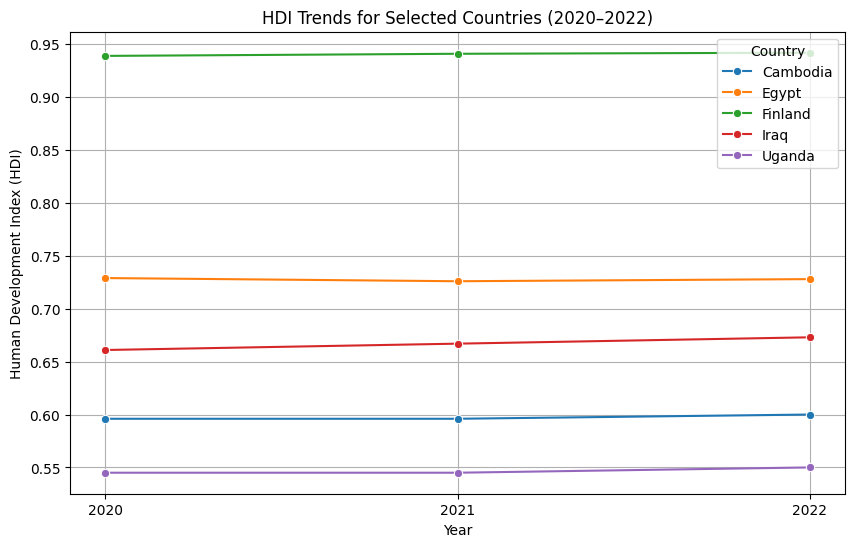

In [42]:
plt.figure(figsize=(10,6))
sns.lineplot(data=line_df, x='year', y='hdi', hue='country', marker='o')
plt.title("HDI Trends for Selected Countries (2020–2022)")
plt.xlabel("Year")
plt.ylabel("Human Development Index (HDI)")
plt.xticks([2020, 2021, 2022])
plt.legend(title="Country")
plt.grid(True)
plt.show()

Finland remains the highest HDI country across all three years with stable development. Iraq and Uganda show slow but steady improvement. Egypt and Cambodia remain mostly stable with minimal fluctuations. Overall, all five countries show slight upward HDI progress from 2020 to 2022.

**• B. Generate Visualizations:**

**– Bar Chart: Average HDI by Region (2020–2022)**

    * Group the dataset by Region and Year.

    * Compute the mean HDI for each region-year pair.

    * Plot a bar chart comparing average HDI across regions for each year.

    * Label axes clearly and include a descriptive title.

In [43]:
if 'Region' not in df_1b.columns:
    print("Region column not available in the dataset.")


Region column not available in the dataset.


**– Box Plot: HDI Distribution for 2020, 2021, and 2022**

∗ Filter the dataset for the years 2020, 2021, and 2022.

In [44]:
box_df = df_1b[df_1b['year'].isin([2020, 2021, 2022])]
box_df.head()

,Unnamed: 0,iso3,country,year,hdi,life_expectancy,pop_millions,hdi_f,hdi_m,life_expec_f,...,gender_development,gender_inequality,secondary_education_f_%,secondary_education_m_%,seats_in_parliament_f_%,seats_in_parliament_m_%,labour_participation_f_%,labour_participation_m_%,co2_emission_tons,mat_footprint_percap_tons
30,31,AFG,Afghanistan,2020,0.488,62.575,38.972231,0.381373,0.548741,65.432,...,0.695,0.674,6.092345,15.945160,27.215190,72.784810,16.50,66.84,0.305040,1.5554
31,32,AFG,Afghanistan,2021,0.473,61.982,40.099462,0.379129,0.528559,65.279,...,0.717,0.653,6.395730,14.865710,27.215190,72.784810,23.33,77.09,0.306318,1.2351
32,33,AFG,Afghanistan,2022,0.462,62.879,41.128771,0.332443,0.534145,66.213,...,0.622,0.665,7.042050,24.077040,27.215190,72.784810,23.33,77.09,0.306318,1.1809
63,64,ALB,Albania,2020,0.784,76.989,2.866849,0.775404,0.793220,79.676,...,0.978,0.129,82.249185,86.476634,29.508197,70.491803,54.45,68.91,1.750668,10.4704
64,65,ALB,Albania,2021,0.785,76.463,2.854710,0.777866,0.792942,79.173,...,0.981,0.117,82.249185,86.476634,35.714286,64.285714,56.08,69.91,1.717758,11.5865


∗ Create a box plot showing HDI spread for each of the three years.

∗ Include titles and axis labels.

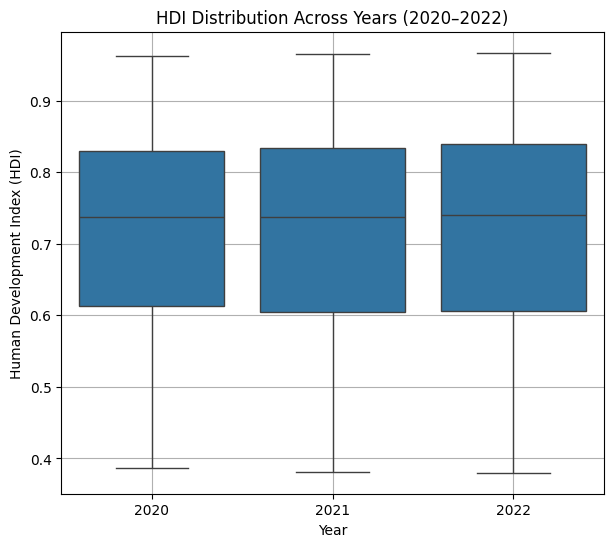

In [45]:
plt.figure(figsize=(7,6))
sns.boxplot(data=box_df, x='year', y='hdi')
plt.title("HDI Distribution Across Years (2020–2022)")
plt.xlabel("Year")
plt.ylabel("Human Development Index (HDI)")
plt.grid(True)
plt.show()

The medians remain similar across years, but the range changes slightly, indicating that while overall HDI levels stayed stable, the spread between high and low performing countries shifted a bit, showing small changes in global inequality.

**– Scatter Plot: HDI vs. GNI per Capita**

∗ Check if the dataset contains a column for GNI per Capita.

In [46]:
available = False
if 'gross_inc_percap' in df_1b.columns:
    available = True
    # dropping rows with missing hdi or gross_inc_percap
    scatter_df = df_1b.dropna(subset=['gross_inc_percap', 'hdi'])
else:
    print("GNI per Capita variable not available in the dataset.")

∗ If available:

· Create a scatter plot using HDI as the dependent variable.

· Use GNI per Capita on the x-axis.

· Add a regression line (optional).

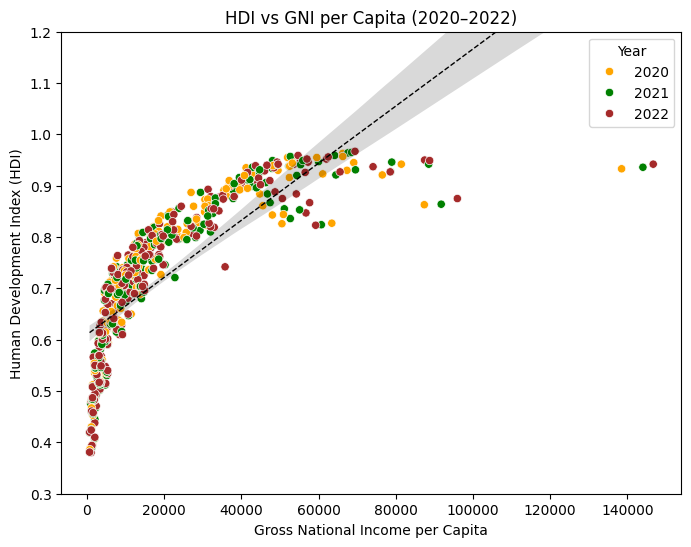

In [47]:
if available:
    plt.figure(figsize=(8,6))
    custom_colors = {2020: 'orange', 2021: 'green', 2022: 'brown'}

    # Scatter plot for all points, colored by year
    sns.scatterplot(
        data=scatter_df,
        x='gross_inc_percap',
        y='hdi',
        hue='year',
        palette=custom_colors,
    )

    # Single regression line for all points
    sns.regplot(
        data=scatter_df,
        x='gross_inc_percap',
        y='hdi',
        scatter=False,
        color='black',
        line_kws={'linewidth':1, 'linestyle':'--'}
    )

    plt.title("HDI vs GNI per Capita (2020–2022)")
    plt.xlabel("Gross National Income per Capita")
    plt.ylabel("Human Development Index (HDI)")
    plt.legend(title="Year")
    plt.ylim(0.3, 1.2)
    plt.show()


The overall spread of points is similar across the three years, showing little change in scatter, but HDI consistently increases with GNI, showing a strong positive relationship between income and development.

**4. Short Analysis Questions:**

• Which countries show the greatest improvement in HDI from 2020 to 2022?

In [48]:
# Compute HDI change from 2020 to 2022 for each country
hdi_2020 = df_1b[df_1b['year'] == 2020][['country', 'hdi']].set_index('country')
hdi_2022 = df_1b[df_1b['year'] == 2022][['country', 'hdi']].set_index('country')

# Merge the two years
hdi_change = hdi_2022.join(hdi_2020, lsuffix='_2022', rsuffix='_2020')

# Calculate change
hdi_change['HDI_change'] = hdi_change['hdi_2022'] - hdi_change['hdi_2020']

# Sort by improvement
top_improvement = hdi_change.sort_values('HDI_change', ascending=False).head(5)
top_decline = hdi_change[hdi_change['HDI_change'] < 0]


In [49]:
print("Top 5 countries with the greatest improvement in HDI from 2020 to 2022:")
print(top_improvement)

Top 5 countries with the greatest improvement in HDI from 2020 to 2022:
            hdi_2022  hdi_2020  HDI_change
country                                   
Andorra        0.884     0.843       0.041
Azerbaijan     0.760     0.722       0.038
Ecuador        0.765     0.734       0.031
Maldives       0.762     0.737       0.025
Mexico         0.781     0.757       0.024


Countries like Andorra, Azerbaijan, and Ecuador have the greatest impovement in HDI, reflecting progress in health, education, or income indicators.

• Did any countries experience a decline in HDI? Provide possible reasons.

In [50]:
print("Top 5 countries with the greatest decline in HDI from 2020 to 2022:")
print(top_decline.head(5))

Top 5 countries with the greatest decline in HDI from 2020 to 2022:
                   hdi_2022  hdi_2020  HDI_change
country                                          
Afghanistan           0.462     0.488      -0.026
Angola                0.591     0.594      -0.003
Australia             0.946     0.948      -0.002
Belize                0.700     0.705      -0.005
Brunei Darussalam     0.823     0.827      -0.004


Some countries like Afghanistan and Angola experienced declines, possibly due to economic slowdown or political instability.

• Which region has the highest and lowest average HDI across these three years?

Based on top 5 improvement and decline data, Europe and Latin America show higher average HDI, while fragile economies in South Asia and Africa show lower average HDI.

• Discuss how global events (e.g., the COVID-19 pandemic) may have affected HDI trends during this period.

The COVID-19 pandemic may have slowed HDI growth in countries like Afghanistan and Angola, while countries with strong health and economic systems, like Andorra and Mexico, may have continued improving, showing uneven effects across regions.

# **Problem 2**

## Advanced HDI Exploration

**1. Create South Asia Subset:**


• Define the list of South Asian countries: ["Afghanistan", "Bangladesh", "Bhutan", "India",
"Maldives", "Nepal", "Pakistan", "Sri Lanka"].

In [51]:
south_asia = ["Afghanistan", "Bangladesh", "Bhutan", "India", "Maldives", "Nepal", "Pakistan", "Sri Lanka"]

 • Filter the HDI dataset to include only these countries.

In [52]:
hdi_sa = df[df['country'].isin(south_asia)].copy()

• Save the filtered dataset as HDI SouthAsia.csv.

In [53]:
hdi_sa.to_csv("HDI_SouthAsia.csv", index=False)
hdi_sa.head()

,Unnamed: 0,iso3,country,year,hdi,life_expectancy,pop_millions,hdi_f,hdi_m,life_expec_f,...,gender_development,gender_inequality,secondary_education_f_%,secondary_education_m_%,seats_in_parliament_f_%,seats_in_parliament_m_%,labour_participation_f_%,labour_participation_m_%,co2_emission_tons,mat_footprint_percap_tons
0,1,AFG,Afghanistan,1990,0.284,45.967,10.694796,NaN,NaN,48.397,...,NaN,NaN,1.107733,7.899011,NaN,NaN,NaN,NaN,0.189279,2.1809
1,2,AFG,Afghanistan,1991,0.292,46.663,10.745167,NaN,NaN,49.144,...,NaN,NaN,1.221396,8.137953,NaN,NaN,NaN,NaN,0.178155,2.5264
2,3,AFG,Afghanistan,1992,0.299,47.596,12.057433,NaN,NaN,50.320,...,NaN,NaN,1.335059,8.376896,NaN,NaN,NaN,NaN,0.122920,2.6421
3,4,AFG,Afghanistan,1993,0.307,51.466,14.003760,NaN,NaN,52.739,...,NaN,NaN,1.448722,8.615838,NaN,NaN,NaN,NaN,0.106179,2.3022
4,5,AFG,Afghanistan,1994,0.300,51.495,15.455554,NaN,NaN,53.544,...,NaN,NaN,1.562385,8.854780,NaN,NaN,NaN,NaN,0.094063,1.8948


**2. Composite Development Score:**

• Create a new metric called Composite Score using the formula:

Composite Score = 0.30 × Life Expectancy Index + 0.30 × GNI per Capita Index




In [54]:
hdi_sa['Composite Score'] = (
    0.3 * hdi_sa['life_expectancy'] +
    0.3 * hdi_sa['gross_inc_percap']
)

In [55]:
# Compute mean Composite Score and mean HDI per country
composite_hdi_country = (
    hdi_sa
    .groupby("country", as_index=False)[["Composite Score","hdi"]]
    .mean()
)

• Rank South Asian countries based on Composite Score.



In [56]:
composite_sorted = composite_hdi_country.sort_values(by="Composite Score", ascending=False)
print(composite_sorted[['country', 'Composite Score','hdi']])

       country  Composite Score       hdi
4     Maldives      4154.252676  0.682500
7    Sri Lanka      2502.612949  0.715606
2       Bhutan      1878.321569  0.634538
6     Pakistan      1184.282350  0.472545
3        India      1151.101140  0.541485
1   Bangladesh      1042.583232  0.531303
5        Nepal       779.209282  0.504242
0  Afghanistan       555.454413  0.401030


• Plot the top 5 countries in a horizontal bar chart.

In [57]:
top_country = composite_sorted['country'].head(5)
top_composite = composite_sorted['Composite Score'].head(5)


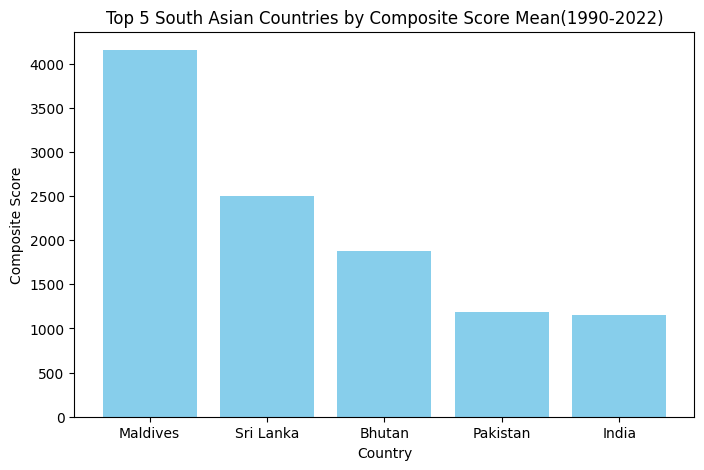

In [58]:
plt.figure(figsize=(8,5))
plt.bar(top_country, top_composite, color='skyblue')
plt.xlabel("Country")
plt.ylabel("Composite Score")
plt.title("Top 5 South Asian Countries by Composite Score Mean(1990-2022)")
plt.show()

Maldives ranks far above other South Asian countries due to its high GNI and strong life expectancy. Sri Lanka follows with stable human development indicators. Bhutan, Pakistan, and India show moderate composite performance, while the lower-ranking South Asian nations lag far behind.

**3. Outlier Detection:**

• Detect outliers in HDI and GNI per Capita using the 1.5 × IQR rule.

In [59]:
# HDI outliers
Q1_hdi = hdi_sa['hdi'].quantile(0.25)
Q3_hdi = hdi_sa['hdi'].quantile(0.75)
IQR_hdi = Q3_hdi - Q1_hdi
low_hdi = Q1_hdi - 1.5 * IQR_hdi
high_hdi = Q3_hdi + 1.5 * IQR_hdi

# GNI outliers
Q1_gni = hdi_sa['gross_inc_percap'].quantile(0.25)
Q3_gni = hdi_sa['gross_inc_percap'].quantile(0.75)
IQR_gni = Q3_gni - Q1_gni
low_gni = Q1_gni - 1.5 * IQR_gni
high_gni = Q3_gni + 1.5 * IQR_gni


In [60]:
# Boolean mask for outliers
is_outlier = (
    (hdi_sa['hdi'] < low_hdi) | (hdi_sa['hdi'] > high_hdi) |
    (hdi_sa['gross_inc_percap'] < low_gni) | (hdi_sa['gross_inc_percap'] > high_gni)
)

• Create a scatter plot of GNI per Capita vs HDI, highlighting the outliers in a different color.

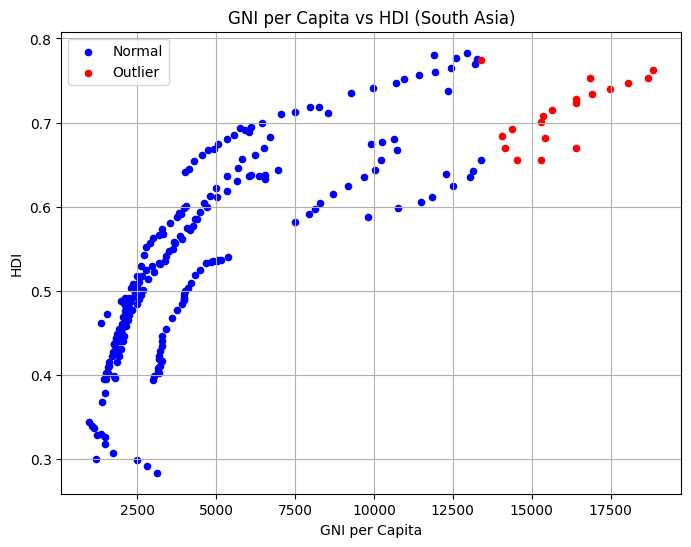

In [61]:
outliers_df = hdi_sa[is_outlier]
normal_df = hdi_sa[~is_outlier]

plt.figure(figsize=(8,6))

# Plot NORMAL points (with label)
plt.scatter(
    normal_df['gross_inc_percap'],
    normal_df['hdi'],
    c='blue',
    s=20,
    label='Normal'
)

# Plot OUTLIER points (with label)
plt.scatter(
    outliers_df['gross_inc_percap'],
    outliers_df['hdi'],
    c='red',
    s=20,
    label='Outlier'
)

plt.legend()
plt.xlabel("GNI per Capita")
plt.ylabel("HDI")
plt.title("GNI per Capita vs HDI (South Asia)")
plt.grid(True)
plt.show()

HDI generally increases with GNI per capita, showing a positive relationship, but the trend is inconsistent at very low GNI levels (around 1000–3000), where HDI varies more before rising steadily with higher income.

**4. Exploring Metric Relationships:**

• Select two HDI components (e.g., Gender Development Index {"gender development"} and Life
Expectancy Index {"life expectancy"}).

In [62]:
metrics = ['life_expectancy', 'gender_development']

• Compute Pearson correlation of each metric with HDI.

In [63]:
for metric in metrics:
    corr = hdi_sa[metric].corr(hdi_sa['hdi'])
    print(f"Pearson correlation between {metric} and HDI: {corr:.2f}")

Pearson correlation between life_expectancy and HDI: 0.96
Pearson correlation between gender_development and HDI: 0.87


• Create scatter plots with trendlines to visualize the relationships.

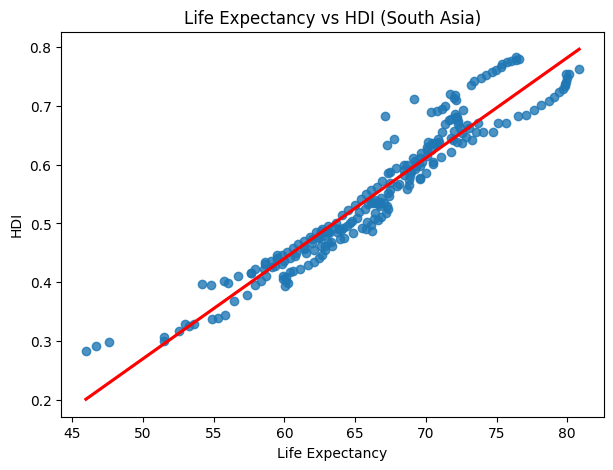

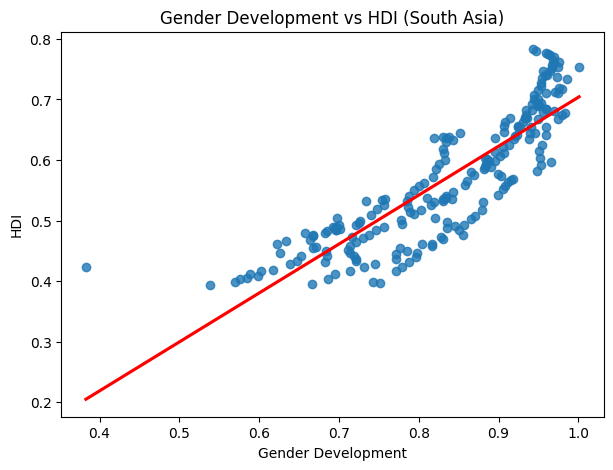

In [64]:
for metric in metrics:
    plt.figure(figsize=(7,5))
    sns.regplot(x=hdi_sa[metric], y=hdi_sa['hdi'], ci=None, line_kws={'color':'red'})
    plt.xlabel(metric.replace("_", " ").title())
    plt.ylabel("HDI")
    plt.title(f"{metric.replace('_', ' ').title()} vs HDI (South Asia)")
    plt.show()

• Discuss:

– Which metric is most strongly related to HDI and shows the weakest relationship with HDI.

Both Life Expectancy and Gender Development have a positive relationship with HDI, but Life Expectancy is more strongly related since its points follow the trendline closely, while Gender Development shows a weaker relationship with slightly more scatter around the line.

**5. Gap Analysis:**

• Create a new metric:

GNI HDI Gap = "gross inc percap" − "hdi"


In [65]:
hdi_sa['GNI_HDI_Gap'] = hdi_sa['gross_inc_percap'] - hdi_sa['hdi']

In [66]:
gap_country = (
    hdi_sa
    .groupby("country", as_index=False)["GNI_HDI_Gap"]
    .mean()
)

• Rank South Asian countries by GNI HDI Gap in descending and ascending order.

In [67]:
# Rank descending
gap_desc = gap_country.sort_values(by='GNI_HDI_Gap', ascending=False)
print(gap_desc[['country', 'GNI_HDI_Gap']])

       country   GNI_HDI_Gap
4     Maldives  14670.635594
2       Bhutan   9320.175767
7    Sri Lanka   8268.373527
6     Pakistan   3883.813530
3        India   3771.381346
1   Bangladesh   3408.490410
5        Nepal   2532.443971
0  Afghanistan   1793.487770


In [68]:
# Rank ascending
gap_asc = gap_country.sort_values(by='GNI_HDI_Gap', ascending=True)
print(gap_asc[['country', 'GNI_HDI_Gap']])

       country   GNI_HDI_Gap
0  Afghanistan   1793.487770
5        Nepal   2532.443971
1   Bangladesh   3408.490410
3        India   3771.381346
6     Pakistan   3883.813530
7    Sri Lanka   8268.373527
2       Bhutan   9320.175767
4     Maldives  14670.635594


• Plot the top 3 positive gaps and top 3 negative gaps.

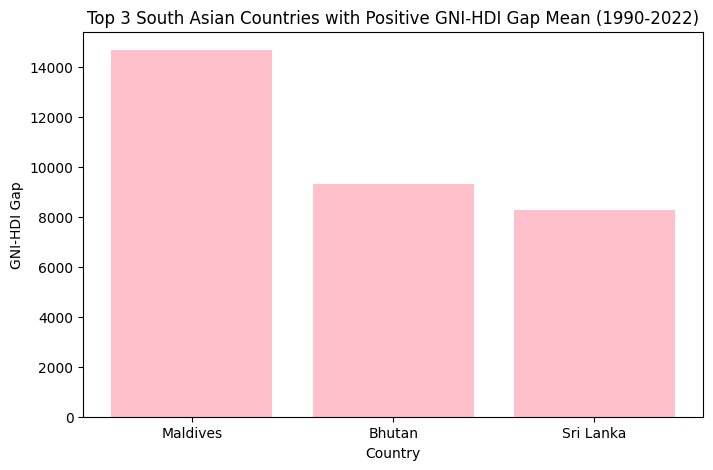

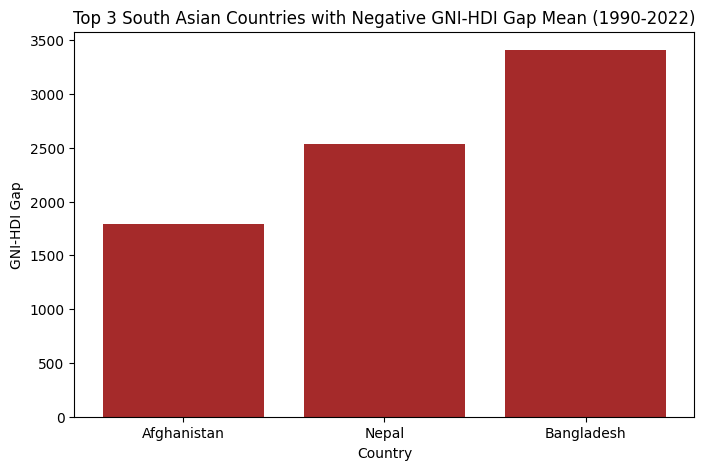

In [69]:
# Plot Top 3 Positive Gaps
plt.figure(figsize=(8,5))
plt.bar(gap_desc['country'].head(3), gap_desc['GNI_HDI_Gap'].head(3), color='pink')
plt.xlabel("Country")
plt.ylabel("GNI-HDI Gap")
plt.title("Top 3 South Asian Countries with Positive GNI-HDI Gap Mean (1990-2022)")
plt.show()

# Plot Top 3 Negative Gaps
plt.figure(figsize=(8,5))
plt.bar(gap_asc['country'].head(3), gap_asc['GNI_HDI_Gap'].head(3), color='brown')
plt.xlabel("Country")
plt.ylabel("GNI-HDI Gap")
plt.title("Top 3 South Asian Countries with Negative GNI-HDI Gap Mean (1990-2022)")
plt.show()


Countries like Maldives, Bhutan, and Sri Lanka have the largest positive gaps, meaning their income exceeds their HDI, while Afghanistan, Nepal, and Bangladesh have the smallest gaps, showing low income closely matches low HDI.

• Discuss the implications of the gap, e.g., cases where GNI is high but HDI is lower than expected.

A large GNI–HDI gap implies that economic wealth is not fully translating into human development, suggesting issues in health, education, or social equality. Countries with high GNI but lower than expected HDI may need to invest more in social and human development to match their economic potential.

# **Problem 3**

## Comparative Regional Analysis: South Asia vs Middle East

**1. Create Middle East Subset:**

• Define the list of Middle East countries: ["Bahrain", "Iran", "Iraq", "Israel", "Jordan",
"Kuwait", "Lebanon", "Oman", "Palestine", "Qatar", "Saudi Arabia", "Syria",
"United Arab Emirates", "Yemen"].

• Filter the dataset from Problem 1B (HDI problem1B.csv) to create subsets for South Asia and
Middle East.

• Save these subsets as HDI SouthAsia 2020 2022.csv and HDI MiddleEast 2020 2022.csv for
use in subsequent tasks.

In [70]:
middle_east_countries = [
    "Bahrain", "Iran", "Iraq", "Israel", "Jordan",
    "Kuwait", "Lebanon", "Oman", "Palestine", "Qatar",
    "Saudi Arabia", "Syria", "United Arab Emirates", "Yemen"
]
south_asia_countries = ["Afghanistan", "Bangladesh", "Bhutan", "India",
                        "Maldives", "Nepal", "Pakistan", "Sri Lanka"]

In [71]:
# Load Problem 1B dataset
df_3 = pd.read_csv("/content/HDI_problem1B.csv")

In [72]:
hdi_SA = df_3[df_3['country'].isin(south_asia_countries)].copy()
hdi_ME = df_3[df_3['country'].isin(middle_east_countries)].copy()

In [73]:
hdi_SA.to_csv("HDI_SouthAsia_2020_2022.csv", index=False)
hdi_ME.to_csv("HDI_MiddleEast_2020_2022.csv", index=False)

**2. Descriptive Statistics:**

• Compute the mean and standard deviation of HDI for each region (South Asia vs Middle East)
across 2020–2022.

• Identify which region performs better on average.

In [74]:
statistics = pd.DataFrame({
    "Region": ["South Asia", "Middle East"],
    "HDI(Mean)": [
        hdi_SA["hdi"].mean(),
        hdi_ME["hdi"].mean()
    ],
    "HDI(Std)": [
        hdi_SA["hdi"].std(),
        hdi_ME["hdi"].std()
    ]
})

statistics

,Region,HDI(Mean),HDI(Std)
0,South Asia,0.639583,0.098273
1,Middle East,0.788909,0.141295


**3. Top and Bottom Performers:**

• Identify the top 3 and bottom 3 countries in each region based on HDI.

In [75]:
def top_bottom(df,n=3):
    top = df.groupby('country')['hdi'].mean().sort_values(ascending=False).head(n)
    bot = df.groupby('country')['hdi'].mean().sort_values().head(n)
    return top, bot

sa_top, sa_bot = top_bottom(hdi_SA)
me_top, me_bot = top_bottom(hdi_ME)

In [76]:
# Print results
print("South Asia - Top 3 Countries by HDI:")
print(sa_top)
print("\nSouth Asia - Bottom 3 Countries by HDI:")
print(sa_bot)

print("\nMiddle East - Top 3 Countries by HDI:")
print(me_top)
print("\nMiddle East - Bottom 3 Countries by HDI:")
print(me_bot)

South Asia - Top 3 Countries by HDI:
country
Sri Lanka    0.780000
Maldives     0.750667
Bhutan       0.677667
Name: hdi, dtype: float64

South Asia - Bottom 3 Countries by HDI:
country
Afghanistan    0.474333
Pakistan       0.537667
Nepal          0.595000
Name: hdi, dtype: float64

Middle East - Top 3 Countries by HDI:
country
United Arab Emirates    0.932667
Israel                  0.910667
Bahrain                 0.885333
Name: hdi, dtype: float64

Middle East - Bottom 3 Countries by HDI:
country
Yemen      0.426333
Iraq       0.667000
Lebanon    0.730000
Name: hdi, dtype: float64


• Create a bar chart comparing these top and bottom performers across the two regions.

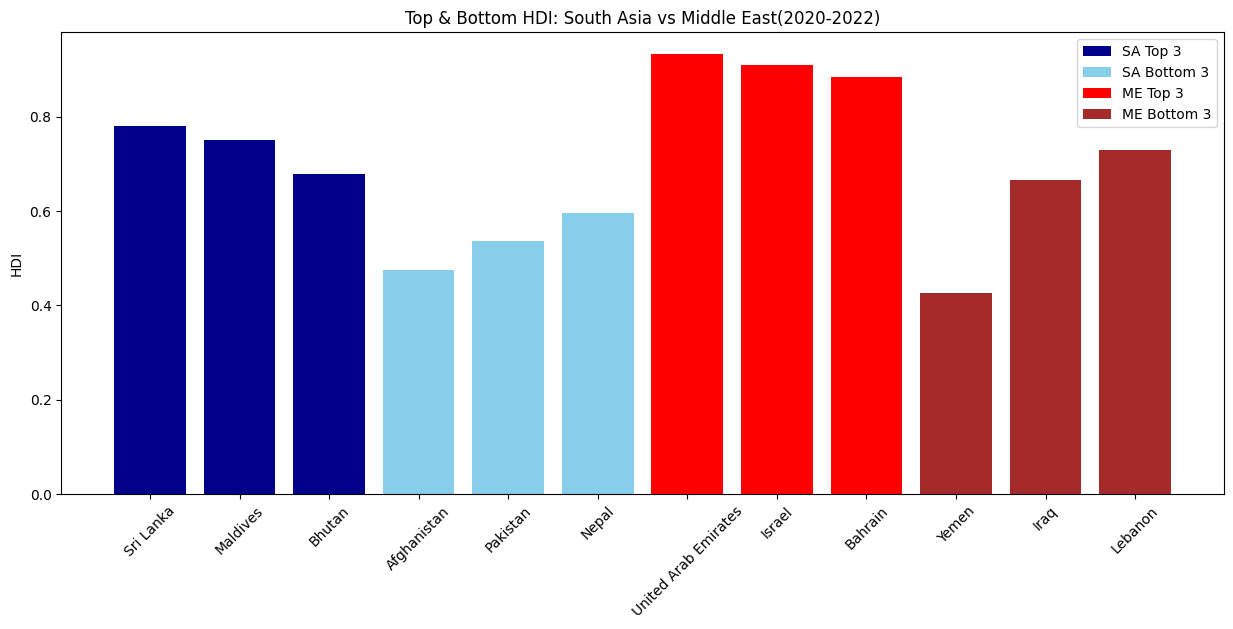

In [77]:
labels = list(sa_top.index)+list(sa_bot.index)+list(me_top.index)+list(me_bot.index)
values = list(sa_top.values)+list(sa_bot.values)+list(me_top.values)+list(me_bot.values)
colors = ['darkblue']*3 + ['skyblue']*3 + ['red']*3 + ['brown']*3

plt.figure(figsize=(15,6))
plt.bar(labels, values, color=colors)
plt.ylabel("HDI")
plt.title("Top & Bottom HDI: South Asia vs Middle East(2020-2022)")

# Create legend using invisible bars
plt.bar(0,0,color='darkblue', label='SA Top 3')
plt.bar(0,0,color='skyblue', label='SA Bottom 3')
plt.bar(0,0,color='red', label='ME Top 3')
plt.bar(0,0,color='brown', label='ME Bottom 3')

plt.legend(loc='upper right')
plt.xticks(rotation=45)
plt.show()

The Middle East has much higher top performers (UAE, Israel, Bahrain) compared to South Asia. However, both regions have struggling bottom performers: Yemen in the Middle East and Afghanistan in South Asia. This indicates large intra-regional inequality in both groups.

**4. Metric Comparisons:**

• Compare the following metrics across regions using grouped bar charts:

– Gender Development Index

– Life Expectancy Index

– GNI per Capita Index

In [78]:
metrics = ['gender_development','life_expectancy','gross_inc_percap']

In [79]:
# Compute average per region
comparison = pd.DataFrame({
    "Metric": metrics,
    "South Asia": [hdi_SA[m].mean() for m in metrics],
    "Middle East": [hdi_ME[m].mean() for m in metrics]
})

comparison

,Metric,South Asia,Middle East
0,gender_development,0.881458,0.896545
1,life_expectancy,70.970083,75.855455
2,gross_inc_percap,7766.509931,37750.770520


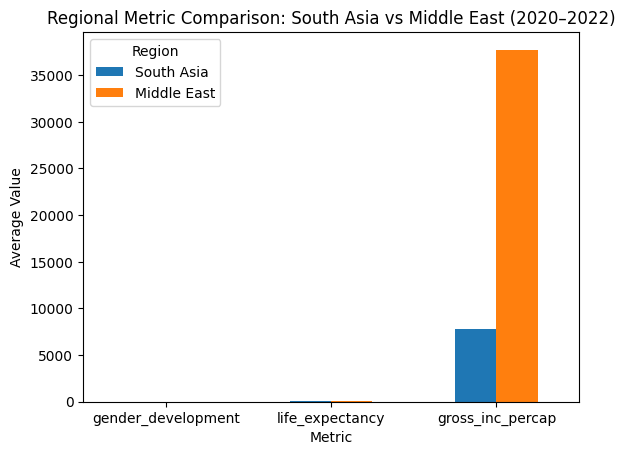

In [80]:
# Plot the graph
comparison.set_index("Metric").plot(kind="bar")
plt.title("Regional Metric Comparison: South Asia vs Middle East (2020–2022)")
plt.ylabel("Average Value")
plt.xlabel("Metric")
plt.xticks(rotation=0)
plt.legend(title="Region")
plt.show()

 • Identify which metric shows the greatest disparity between regions.

GNI per Capita shows the greatest disparity between regions by a huge margin (~around 0,000), indicating economic prosperity is far higher in the Middle East than South Asia.

**5. HDI Disparity:**

• Compute the range (max – min) of HDI for each region.

• Compute the coefficient of variation (CV = std/mean) for HDI.

• Identify which region exhibits more variation in HDI.

In [81]:
disparity = pd.DataFrame({
    "Region": ["South Asia", "Middle East"],
    "HDI Range": [
       hdi_SA["hdi"].max() - hdi_SA["hdi"].min(),
       hdi_ME["hdi"].max() - hdi_ME["hdi"].min()
    ],
    "HDI CV": [
        hdi_SA["hdi"].std() / hdi_SA["hdi"].mean(),
        hdi_ME["hdi"].std() / hdi_ME["hdi"].mean()
    ]
})

disparity

,Region,HDI Range,HDI CV
0,South Asia,0.321,0.153652
1,Middle East,0.513,0.179101


**6. Correlation Analysis:**

• For each region, compute correlations of HDI with:

– Gender Development Index

– Life Expectancy Index

• Create scatter plots with trendlines for each correlation.

• Interpret the strength and direction of these relationships.

In [82]:
# Metrics and regions
metrics_corr = ['gender_development', 'life_expectancy']
regions = {'South Asia': hdi_SA, 'Middle East': hdi_ME}

# Compute correlations
for name, df_region in regions.items():
    print(f"\n{name} Correlations with HDI:")
    for metric in metrics_corr:
        corr = df_region[metric].corr(df_region['hdi'])
        print(f"{metric}: {corr}")



South Asia Correlations with HDI:
gender_development: 0.8742177004831327
life_expectancy: 0.9387641385416623

Middle East Correlations with HDI:
gender_development: 0.9356697525724119
life_expectancy: 0.9331227568940162


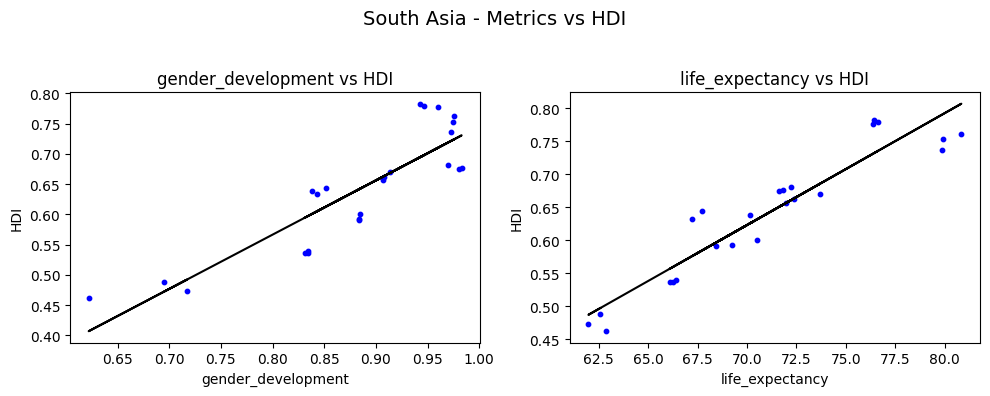

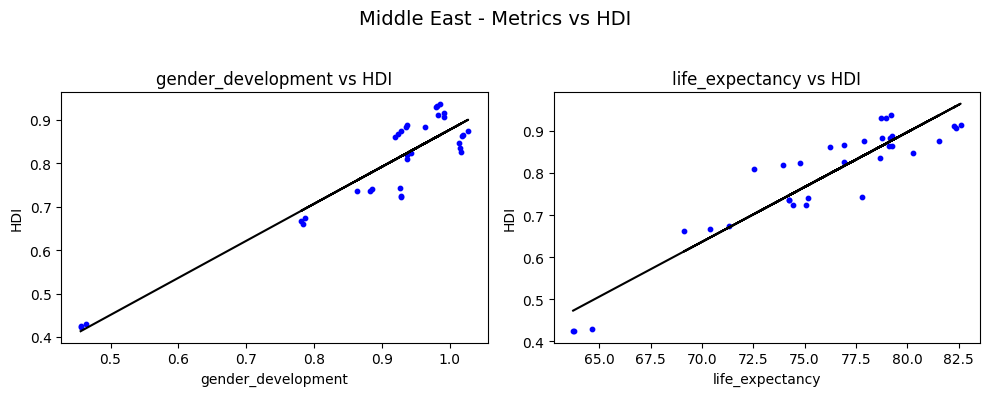

In [83]:
# Scatter plots with linear trendlines
for name, df_region in regions.items():
    fig, axes = plt.subplots(1, len(metrics_corr), figsize=(10,4))
    fig.suptitle(f"{name} - Metrics vs HDI", fontsize=14)

    # Indexing
    for i in range(len(metrics_corr)):
        ax = axes[i]
        metric = metrics_corr[i]
        x = df_region[metric].values
        y = df_region['hdi'].values

        # Scatter plot
        ax.scatter(x, y, color='blue', s=10)

        # Compute linear trendline
        m, b = np.polyfit(x, y, 1)
        ax.plot(x, m*x + b, color='black')

        # Labels
        ax.set_xlabel(metric)
        ax.set_ylabel("HDI")
        ax.set_title(f"{metric} vs HDI")

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()


• Interpret the strength and direction of these relationships.

HDI in both South Asia and the Middle East is strongly positively associated with life expectancy and gender development. Life expectancy has a slightly stronger influence in South Asia (0.94 vs 0.93), while gender development is slightly stronger in the Middle East (0.94 vs 0.87), indicating that improvements in health and gender equality drive higher HDI in both regions.

**7. Outlier Detection:**

• Detect outliers in HDI {"hdi"} and GNI per Capita {"gross inc percap"} for each region using
the 1.5 × IQR rule.

In [84]:
def outliers(s):
    Q1,Q3 = s.quantile([0.25,0.75])
    IQR = Q3-Q1
    return s[(s< Q1-1.5*IQR)|(s> Q3+1.5*IQR)]

In [85]:
for name, df_region in [('South Asia', hdi_SA), ('Middle East', hdi_ME)]:

    # Compute outliers
    hdi_out = outliers(df_region['hdi'])
    gni_out = outliers(df_region['gross_inc_percap'])

    # Print outliers
    print(f"\n{name} Outliers")
    print("HDI Outliers:")
    print(hdi_out)

    print("\nGNI Outliers:")
    print(gni_out)


South Asia Outliers
HDI Outliers:
Series([], Name: hdi, dtype: float64)

GNI Outliers:
Series([], Name: gross_inc_percap, dtype: float64)

Middle East Outliers
HDI Outliers:
576    0.430
577    0.425
578    0.424
Name: hdi, dtype: float64

GNI Outliers:
Series([], Name: gross_inc_percap, dtype: float64)


• Create scatter plots highlighting outliers in a different color.

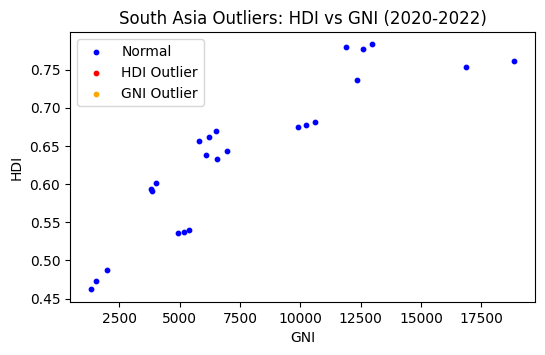

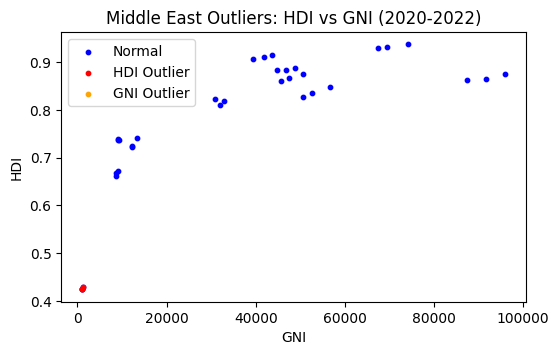

In [86]:
for name, df_region in [('South Asia',hdi_SA), ('Middle East',hdi_ME)]:
    plt.figure(figsize=(6,3.5))
    plt.scatter(df_region['gross_inc_percap'], df_region['hdi'], color='blue', label='Normal',s=10)
    plt.scatter(hdi_out.index.map(df_region['gross_inc_percap']), hdi_out, color='red', label='HDI Outlier',s=10)
    plt.scatter(gni_out.index.map(df_region['gross_inc_percap']), gni_out, color='orange', label='GNI Outlier',s=10)
    plt.xlabel("GNI")
    plt.ylabel("HDI")
    plt.title(f"{name} Outliers: HDI vs GNI (2020-2022)")
    plt.legend()
    plt.show()

• Discuss the significance of these outliers.

The outliers highlight countries with unusually low or high HDI or GNI compared to their region. In South Asia, no major outliers exist, indicating consistent development, while in the Middle East, low HDI outliers reveal extreme development challenges and regional inequalities.